# Week 5 Project: Customer Sales Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Datasets

In [3]:
sales = pd.read_csv(r"C:\Users\hande\Downloads\sales_data (2).csv")
customers = pd.read_csv(r"C:\Users\hande\Downloads\customer_churn.csv")

# Display First Five Rows

In [4]:
sales.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [5]:
customers.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


# Check Dataset Information

In [6]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [7]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


# Check Dataset Shape

In [8]:
sales.shape

(100, 7)

In [9]:
customers.shape

(500, 9)

# Check Missing Values

In [10]:
sales.isnull().sum()

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

In [11]:
customers.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

# Remove Duplicate Records

In [12]:
sales.drop_duplicates(inplace=True)

customers.drop_duplicates(inplace=True)

# Fill Missing Values

In [13]:
sales.fillna(0, inplace=True)

customers.fillna("Unknown", inplace=True)

# Convert Date Column

In [14]:
sales.dtypes

Date           object
Product        object
Quantity        int64
Price           int64
Customer_ID    object
Region         object
Total_Sales     int64
dtype: object

In [15]:
sales["Date"].head(10)

0    2024-01-01
1    2024-01-02
2    2024-01-03
3    2024-01-04
4    2024-01-05
5    2024-01-06
6    2024-01-07
7    2024-01-08
8    2024-01-09
9    2024-01-10
Name: Date, dtype: object

In [16]:
sales["Date"] = pd.to_datetime(sales["Date"])

In [17]:
sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month_name()
sales["Day"] = sales["Date"].dt.day

# String Operations

In [26]:

customers.rename(columns={"CustomerID": "Customer_ID"}, inplace=True)

# Merge the datasets

In [28]:
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")

In [29]:
# Total Customers
sales["Customer_ID"].nunique()

# Total Revenue
sales["Total_Sales"].sum()

# Top Customers
sales.groupby("Customer_ID")["Total_Sales"].sum().sort_values(ascending=False).head(10)

# Sales by Region
sales.groupby("Region")["Total_Sales"].sum()

# Best Selling Products
sales.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

# Monthly Sales
sales["Date"] = pd.to_datetime(sales["Date"])
sales["Month"] = sales["Date"].dt.to_period("M")
sales.groupby("Month")["Total_Sales"].sum()

Month
2024-01    4120524
2024-02    2656050
2024-03    4485006
2024-04    1103468
Freq: M, Name: Total_Sales, dtype: int64

# Multiple Condition Filtering (AND)

In [39]:


sales[
    (sales["Region"] == "East") &
    (sales["Total_Sales"] > 500)
]

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,2024-01,1
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,2024-01,4
12,2024-01-13,Phone,8,20655,CUST013,East,165240,2024,2024-01,13
13,2024-01-14,Headphones,4,4195,CUST014,East,16780,2024,2024-01,14
20,2024-01-21,Laptop,3,36518,CUST021,East,109554,2024,2024-01,21
30,2024-01-31,Tablet,6,34900,CUST031,East,209400,2024,2024-01,31
33,2024-02-03,Tablet,2,48602,CUST034,East,97204,2024,2024-02,3
35,2024-02-05,Tablet,4,45515,CUST036,East,182060,2024,2024-02,5
37,2024-02-07,Monitor,8,19256,CUST038,East,154048,2024,2024-02,7
44,2024-02-14,Phone,2,40244,CUST045,East,80488,2024,2024-02,14


# Multiple Condition Filtering (OR)

In [42]:


sales[
    (sales["Region"] == "East") |
    (sales["Region"] == "West")
]

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,Day
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,2024-01,1
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,2024-01,3
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,2024-01,4
7,2024-01-08,Laptop,7,7262,CUST008,West,50834,2024,2024-01,8
9,2024-01-10,Laptop,4,45023,CUST010,West,180092,2024,2024-01,10
10,2024-01-11,Monitor,8,6160,CUST011,West,49280,2024,2024-01,11
11,2024-01-12,Phone,2,13233,CUST012,West,26466,2024,2024-01,12
12,2024-01-13,Phone,8,20655,CUST013,East,165240,2024,2024-01,13
13,2024-01-14,Headphones,4,4195,CUST014,East,16780,2024,2024-01,14
14,2024-01-15,Headphones,2,34447,CUST015,West,68894,2024,2024-01,15


# Aggregation 1 (Sum)

In [44]:



sales.groupby("Region")["Total_Sales"].sum()

Region
East     2519639
North    3983635
South    3737852
West     2123922
Name: Total_Sales, dtype: int64

# Aggregation 2 (Mean)

In [46]:


sales.groupby("Region")["Total_Sales"].mean()

Region
East     132612.578947
North    142272.678571
South    138438.962963
West      81689.307692
Name: Total_Sales, dtype: float64

# Aggregation 3 (Count)

In [48]:

sales.groupby("Region")["Total_Sales"].count()
sales.groupby("Region")["Customer_ID"].count()

Region
East     19
North    28
South    27
West     26
Name: Customer_ID, dtype: int64

# Create Pivot Table

In [50]:




pivot = pd.pivot_table(
    sales,
    values="Total_Sales",
    index="Region",
    aggfunc="sum"
)

pivot

,Total_Sales
Region,
East,2519639
North,3983635
South,3737852
West,2123922


# Monthly Sales Chart

In [55]:
print(sales.head())
print(sales.columns.tolist())
print(sales.dtypes)

        Date     Product  Quantity  Price Customer_ID Region  Total_Sales  \
0 2024-01-01       Phone         7  37300     CUST001   East       261100   
1 2024-01-02  Headphones         4  15406     CUST002  North        61624   
2 2024-01-03       Phone         2  21746     CUST003   West        43492   
3 2024-01-04  Headphones         1  30895     CUST004   East        30895   
4 2024-01-05      Laptop         8  39835     CUST005  North       318680   

   Year    Month  Day  
0  2024  2024-01    1  
1  2024  2024-01    2  
2  2024  2024-01    3  
3  2024  2024-01    4  
4  2024  2024-01    5  
['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales', 'Year', 'Month', 'Day']
Date           datetime64[ns]
Product                object
Quantity                int64
Price                   int64
Customer_ID            object
Region                 object
Total_Sales             int64
Year                    int32
Month               period[M]
Day               

In [56]:
monthly = sales.groupby("Month")["Total_Sales"].sum()

print(monthly)

Month
2024-01    4120524
2024-02    2656050
2024-03    4485006
2024-04    1103468
Freq: M, Name: Total_Sales, dtype: int64


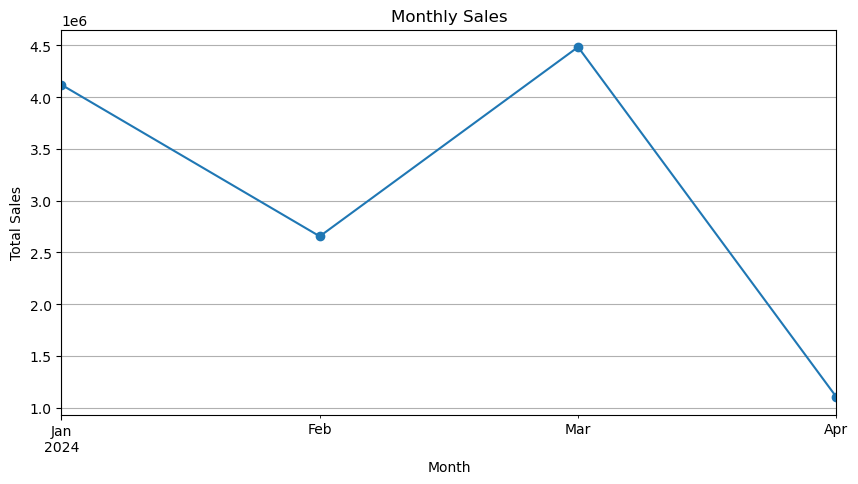

In [57]:
import matplotlib.pyplot as plt

monthly.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# Top Customers Chart

In [59]:
top = sales.groupby("Customer_ID")["Total_Sales"].sum().nlargest(10)

print(top)

Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: Total_Sales, dtype: int64


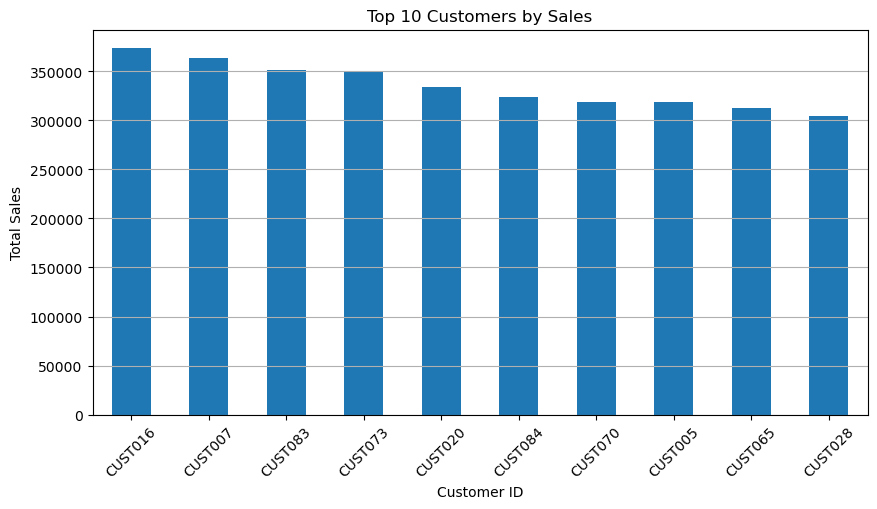

In [61]:


import matplotlib.pyplot as plt

top.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()





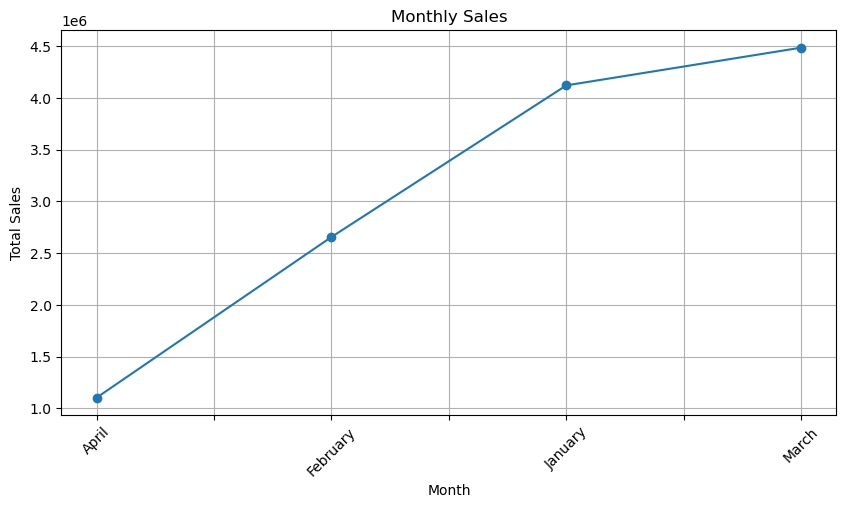

In [62]:
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
sales["Month"] = sales["Date"].dt.month_name()

monthly = sales.groupby("Month")["Total_Sales"].sum()

monthly.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Regional Sales Pie Chart

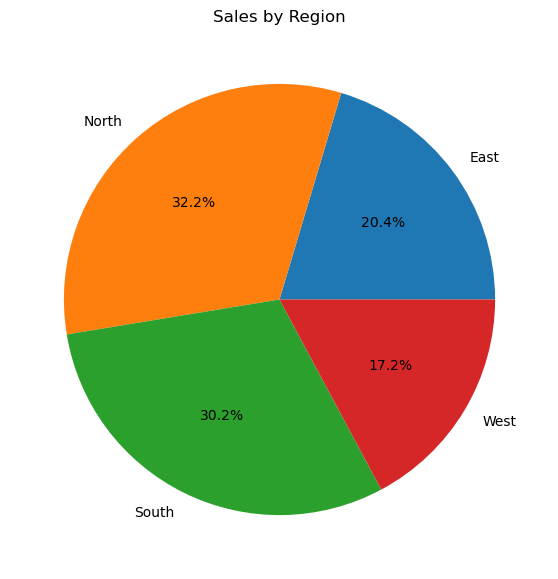

In [64]:


region = sales.groupby("Region")["Total_Sales"].sum()

region.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Sales by Region")
plt.ylabel("")
plt.show()

# Product Sales Bar Chart

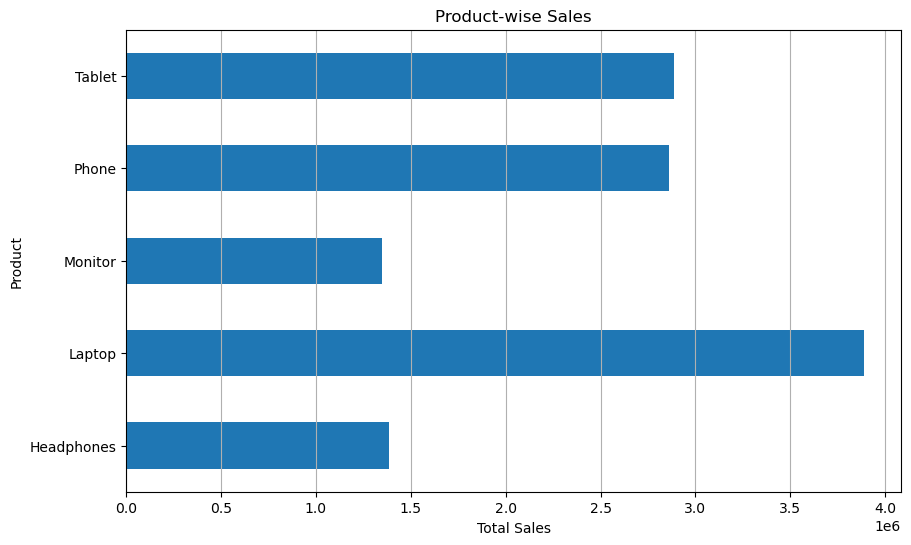

In [66]:


product = sales.groupby("Product")["Total_Sales"].sum()

product.plot(kind="barh", figsize=(10,6))
plt.title("Product-wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.grid(axis="x")
plt.show()

# Revenue Distribution Histogram

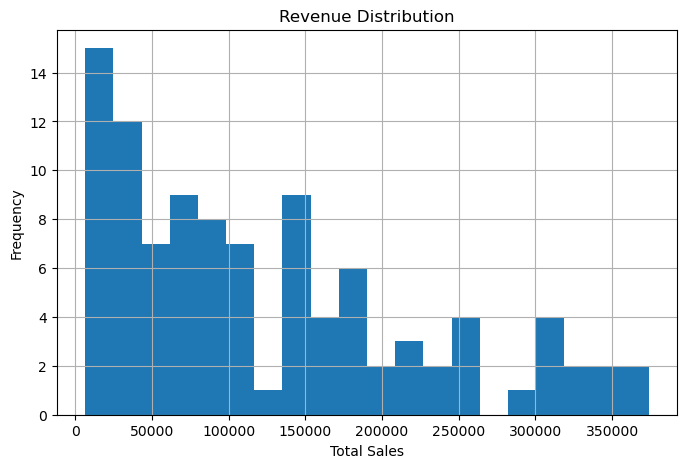

In [69]:


sales["Total_Sales"].plot(
    kind="hist",
    bins=20,
    figsize=(8,5)
)

plt.title("Revenue Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()